In [363]:
import pandas as pd
import numpy as np
import statsmodels.formula.api as smf
import statsmodels.api as sm
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score,
    roc_auc_score, confusion_matrix
)

In [364]:
3# Load neighborhood home value index data
ne_df=pd.read_csv('Metro_zhvi_uc_sfrcondo_tier_0.33_0.67_sm_sa_month.csv')
ne_df.head()

,RegionID,SizeRank,RegionName,RegionType,StateName,2000-01-31,2000-02-29,2000-03-31,2000-04-30,2000-05-31,...,2025-01-31,2025-02-28,2025-03-31,2025-04-30,2025-05-31,2025-06-30,2025-07-31,2025-08-31,2025-09-30,2025-10-31
0,102001,0,United States,country,NaN,122095.338389,122310.143231,122576.532861,123147.886331,123805.445673,...,362348.966564,362807.919409,362533.073508,362005.958620,361321.678348,360705.615411,360279.804203,360052.608231,360293.712117,360727.121788
1,394913,1,"New York, NY",msa,NY,219565.593260,220498.623149,221440.294575,223348.485266,225324.482808,...,689682.577780,690983.193638,692691.217545,695141.260958,696921.202994,698406.123120,699586.052632,700381.032667,701790.451814,704140.723119
2,753899,2,"Los Angeles, CA",msa,CA,221432.437164,222256.446781,223354.019733,225537.821205,227926.215390,...,963545.812288,961517.697095,956424.504253,952110.252154,947340.204517,942988.929116,940398.465432,939327.828380,940383.909291,942798.595192
3,394463,3,"Chicago, IL",msa,IL,153343.175465,153485.126575,153755.474965,154428.034572,155237.042883,...,328627.381612,329973.195016,330818.586508,331419.158957,331709.573240,332070.288234,332909.054962,333904.160604,335236.319083,336540.250584
4,394514,4,"Dallas, TX",msa,TX,127434.269550,127491.029219,127556.280269,127725.730391,127949.145738,...,374885.871571,374099.667668,372599.443330,370475.677803,368063.324701,365702.998441,363689.498266,362329.533893,361683.472342,361335.422264


In [365]:
# Load sales count data
sales_df=pd.read_csv('Metro_sales_count_raw_uc_sfr_month.csv')
sales_df.head()

,RegionID,SizeRank,RegionName,RegionType,StateName,2008-02-29,2008-03-31,2008-04-30,2008-05-31,2008-06-30,...,2024-12-31,2025-01-31,2025-02-28,2025-03-31,2025-04-30,2025-05-31,2025-06-30,2025-07-31,2025-08-31,2025-09-30
0,102001,0,United States,country,NaN,181231.0,209499.0,232845.0,257626.0,270505.0,...,252493.0,202640.0,208495.0,255714.0,287307.0,313034.0,320634.0,318326.0,303104.0,287589.0
1,394913,1,"New York, NY",msa,NY,5713.0,6155.0,7012.0,7391.0,8200.0,...,9435.0,8078.0,6468.0,7569.0,7948.0,8774.0,9733.0,10715.0,10500.0,9481.0
2,753899,2,"Los Angeles, CA",msa,CA,3189.0,3881.0,4718.0,5321.0,5668.0,...,4755.0,3593.0,4084.0,4856.0,5510.0,5348.0,5286.0,5539.0,5098.0,5276.0
3,394463,3,"Chicago, IL",msa,IL,3833.0,4688.0,5085.0,5592.0,6263.0,...,5279.0,4328.0,4063.0,5053.0,6011.0,6662.0,7397.0,7277.0,6650.0,6234.0
4,394514,4,"Dallas, TX",msa,TX,4819.0,5525.0,5909.0,6608.0,6620.0,...,5318.0,4143.0,4872.0,6017.0,6505.0,7031.0,6883.0,6932.0,6402.0,5831.0


In [366]:
# Load transaction value data
trans_df=pd.read_csv('Metro_total_transaction_value_uc_sfr_month.csv')
trans_df.head()

,RegionID,SizeRank,RegionName,RegionType,StateName,2008-02-29,2008-03-31,2008-04-30,2008-05-31,2008-06-30,...,2024-12-31,2025-01-31,2025-02-28,2025-03-31,2025-04-30,2025-05-31,2025-06-30,2025-07-31,2025-08-31,2025-09-30
0,102001,0,United States,country,NaN,4.339785e+10,5.084359e+10,5.736831e+10,6.402455e+10,6.886239e+10,...,1.210843e+11,9.726066e+10,1.016448e+11,1.283367e+11,1.456258e+11,1.594912e+11,1.664526e+11,1.620148e+11,1.534936e+11,1.441419e+11
1,394913,1,"New York, NY",msa,NY,2.873535e+09,3.042245e+09,3.535158e+09,3.710610e+09,4.132016e+09,...,7.566778e+09,6.817774e+09,5.268231e+09,6.325778e+09,6.797896e+09,7.606459e+09,8.799570e+09,9.625750e+09,9.528387e+09,8.179942e+09
2,753899,2,"Los Angeles, CA",msa,CA,2.157483e+09,2.551486e+09,3.105880e+09,3.311662e+09,3.531301e+09,...,6.339663e+09,4.895233e+09,5.803274e+09,7.021893e+09,7.644251e+09,7.416829e+09,7.503811e+09,7.803497e+09,6.975712e+09,7.193730e+09
3,394463,3,"Chicago, IL",msa,IL,1.064231e+09,1.354100e+09,1.432122e+09,1.604104e+09,1.884355e+09,...,2.097606e+09,1.716387e+09,1.601767e+09,2.130219e+09,2.623107e+09,2.972538e+09,3.593417e+09,3.323994e+09,3.061062e+09,2.723482e+09
4,394514,4,"Dallas, TX",msa,TX,9.187468e+08,1.082120e+09,1.175077e+09,1.395420e+09,1.378522e+09,...,2.659695e+09,1.985652e+09,2.364316e+09,3.096534e+09,3.374227e+09,3.686670e+09,3.683830e+09,3.610742e+09,3.227807e+09,2.856210e+09


In [367]:
# Parameters
target_states=['MA','NH','CT']
start_date='2019-01-01'
end_date='2024-12-31'

In [368]:
# Helper function to clean ANY "Monthly" Zillow dataset
def clean_monthly_data(df, value_name):
    # Filter for target states
    df_filtered = df[df['StateName'].isin(target_states)].copy()
    
    # Identify ID cols and Date cols
    id_cols = ['RegionID', 'SizeRank', 'RegionName', 'RegionType', 'StateName']
    date_cols = [c for c in df.columns if c not in id_cols]
    
    # Melt to long format
    df_long = pd.melt(df_filtered, id_vars=id_cols, value_vars=date_cols, 
                      var_name='Date', value_name=value_name)
    
    # Convert Date column to datetime
    df_long['Date'] = pd.to_datetime(df_long['Date'])
    
    # Filter by the date range
    df_long = df_long[(df_long['Date'] >= start_date) & (df_long['Date'] <= end_date)]
    
    # Ensure dates are set to the end of the month (harmonizes 2019-01-01 with 2019-01-31)
    df_long['Date'] = df_long['Date'] + pd.offsets.MonthEnd(0)
    
    return df_long

In [369]:
# Clean each dataset
clean_ne = clean_monthly_data(ne_df, 'Zillow_Home_Value_Index')
clean_sales = clean_monthly_data(sales_df, 'Sales_Count')
clean_trans = clean_monthly_data(trans_df, 'Total_Transaction_Value')

In [370]:
# Checks clean_ne df for missing values
clean_ne.info()

<class 'pandas.core.frame.DataFrame'>
Index: 1152 entries, 3648 to 4799
Data columns (total 7 columns):
 #   Column                   Non-Null Count  Dtype         
---  ------                   --------------  -----         
 0   RegionID                 1152 non-null   int64         
 1   SizeRank                 1152 non-null   int64         
 2   RegionName               1152 non-null   object        
 3   RegionType               1152 non-null   object        
 4   StateName                1152 non-null   object        
 5   Date                     1152 non-null   datetime64[ns]
 6   Zillow_Home_Value_Index  1152 non-null   float64       
dtypes: datetime64[ns](1), float64(1), int64(2), object(3)
memory usage: 72.0+ KB


In [371]:
# Checks clean_sales df for missing values
clean_sales.info()

<class 'pandas.core.frame.DataFrame'>
Index: 1224 entries, 2227 to 3450
Data columns (total 7 columns):
 #   Column       Non-Null Count  Dtype         
---  ------       --------------  -----         
 0   RegionID     1224 non-null   int64         
 1   SizeRank     1224 non-null   int64         
 2   RegionName   1224 non-null   object        
 3   RegionType   1224 non-null   object        
 4   StateName    1224 non-null   object        
 5   Date         1224 non-null   datetime64[ns]
 6   Sales_Count  1224 non-null   float64       
dtypes: datetime64[ns](1), float64(1), int64(2), object(3)
memory usage: 76.5+ KB


In [372]:
# Checks clean_trans df for missing values
clean_trans.info()

<class 'pandas.core.frame.DataFrame'>
Index: 1224 entries, 2227 to 3450
Data columns (total 7 columns):
 #   Column                   Non-Null Count  Dtype         
---  ------                   --------------  -----         
 0   RegionID                 1224 non-null   int64         
 1   SizeRank                 1224 non-null   int64         
 2   RegionName               1224 non-null   object        
 3   RegionType               1224 non-null   object        
 4   StateName                1224 non-null   object        
 5   Date                     1224 non-null   datetime64[ns]
 6   Total_Transaction_Value  1150 non-null   float64       
dtypes: datetime64[ns](1), float64(1), int64(2), object(3)
memory usage: 76.5+ KB


In [373]:
# Calculate mean transaction value
mean_trans = clean_trans['Total_Transaction_Value'].mean()

In [374]:
# Impute missing transaction values with the mean
clean_trans.fillna(mean_trans, inplace=True)
clean_trans.info()

<class 'pandas.core.frame.DataFrame'>
Index: 1224 entries, 2227 to 3450
Data columns (total 7 columns):
 #   Column                   Non-Null Count  Dtype         
---  ------                   --------------  -----         
 0   RegionID                 1224 non-null   int64         
 1   SizeRank                 1224 non-null   int64         
 2   RegionName               1224 non-null   object        
 3   RegionType               1224 non-null   object        
 4   StateName                1224 non-null   object        
 5   Date                     1224 non-null   datetime64[ns]
 6   Total_Transaction_Value  1224 non-null   float64       
dtypes: datetime64[ns](1), float64(1), int64(2), object(3)
memory usage: 76.5+ KB


In [375]:
merge_keys = ['RegionID', 'SizeRank', 'RegionName', 'RegionType', 'StateName', 'Date']


In [376]:
# Merge Home Value + Sales Count
combined_df = pd.merge(clean_ne, clean_sales, on=merge_keys, how='outer')

# Merge + Transaction Value
combined_df = pd.merge(combined_df, clean_trans, on=merge_keys, how='outer')

# Final Sort
combined_df = combined_df.sort_values(by=['StateName', 'RegionName', 'Date']).reset_index(drop=True)

In [377]:
# Check the result
print(f"Data range: {combined_df['Date'].min()} to {combined_df['Date'].max()}")
print(f"Shape: {combined_df.shape}")
combined_df.head()

Data range: 2019-01-31 00:00:00 to 2024-12-31 00:00:00
Shape: (1224, 9)


,RegionID,SizeRank,RegionName,RegionType,StateName,Date,Zillow_Home_Value_Index,Sales_Count,Total_Transaction_Value
0,394415,60,"Bridgeport, CT",msa,CT,2019-01-31,416267.054393,501.0,304543977.0
1,394415,60,"Bridgeport, CT",msa,CT,2019-02-28,415667.646257,450.0,246104652.0
2,394415,60,"Bridgeport, CT",msa,CT,2019-03-31,415657.779585,539.0,307190816.0
3,394415,60,"Bridgeport, CT",msa,CT,2019-04-30,416112.979885,674.0,449565742.0
4,394415,60,"Bridgeport, CT",msa,CT,2019-05-31,416072.181841,904.0,588791446.0


In [378]:
cols_to_drop = ['SizeRank', 'RegionType']
new_combined_df = combined_df.drop(columns=cols_to_drop)

In [379]:
new_combined_df.head()

,RegionID,RegionName,StateName,Date,Zillow_Home_Value_Index,Sales_Count,Total_Transaction_Value
0,394415,"Bridgeport, CT",CT,2019-01-31,416267.054393,501.0,304543977.0
1,394415,"Bridgeport, CT",CT,2019-02-28,415667.646257,450.0,246104652.0
2,394415,"Bridgeport, CT",CT,2019-03-31,415657.779585,539.0,307190816.0
3,394415,"Bridgeport, CT",CT,2019-04-30,416112.979885,674.0,449565742.0
4,394415,"Bridgeport, CT",CT,2019-05-31,416072.181841,904.0,588791446.0


In [380]:
new_combined_df.tail()

,RegionID,RegionName,StateName,Date,Zillow_Home_Value_Index,Sales_Count,Total_Transaction_Value
1219,394820,"Manchester, NH",NH,2024-08-31,489937.532536,350.0,197250956.0
1220,394820,"Manchester, NH",NH,2024-09-30,492015.517108,300.0,165425042.0
1221,394820,"Manchester, NH",NH,2024-10-31,494363.396239,284.0,161063836.0
1222,394820,"Manchester, NH",NH,2024-11-30,496197.364383,276.0,146871379.0
1223,394820,"Manchester, NH",NH,2024-12-31,498084.329504,257.0,141388162.0


In [381]:
new_combined_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1224 entries, 0 to 1223
Data columns (total 7 columns):
 #   Column                   Non-Null Count  Dtype         
---  ------                   --------------  -----         
 0   RegionID                 1224 non-null   int64         
 1   RegionName               1224 non-null   object        
 2   StateName                1224 non-null   object        
 3   Date                     1224 non-null   datetime64[ns]
 4   Zillow_Home_Value_Index  1152 non-null   float64       
 5   Sales_Count              1224 non-null   float64       
 6   Total_Transaction_Value  1224 non-null   float64       
dtypes: datetime64[ns](1), float64(3), int64(1), object(2)
memory usage: 67.1+ KB


In [382]:
metro_ref = {
    'Boston, MA': {'Zip': '02108', 'Lat': 42.3601, 'Lon': -71.0589},
    'Worcester, MA': {'Zip': '01608', 'Lat': 42.2626, 'Lon': -71.8023},
    'Springfield, MA': {'Zip': '01103', 'Lat': 42.1015, 'Lon': -72.5898},
    'Barnstable Town, MA': {'Zip': '02601', 'Lat': 41.6518, 'Lon': -70.2837},
    'Pittsfield, MA': {'Zip': '01201', 'Lat': 42.4501, 'Lon': -73.2454},
    'Manchester, NH': {'Zip': '03101', 'Lat': 42.9956, 'Lon': -71.4548},
    'Nashua, NH': {'Zip': '03060', 'Lat': 42.7654, 'Lon': -71.4676},
    'Concord, NH': {'Zip': '03301', 'Lat': 43.2081, 'Lon': -71.5376},
    'Claremont, NH': {'Zip': '03743', 'Lat': 43.3765, 'Lon': -72.3473},
    'Keene, NH': {'Zip': '03431', 'Lat': 42.9201, 'Lon': -72.2968},
    'Laconia, NH': {'Zip': '03246', 'Lat': 43.5279, 'Lon': -71.4704},
    'Berlin, NH': {'Zip': '03570', 'Lat': 44.4687, 'Lon': -71.1851},
    'Hartford, CT': {'Zip': '06103', 'Lat': 41.7658, 'Lon': -72.6734},
    'New Haven, CT': {'Zip': '06510', 'Lat': 41.3083, 'Lon': -72.9279},
    'Bridgeport, CT': {'Zip': '06604', 'Lat': 41.1792, 'Lon': -73.1919},
    'Stamford, CT': {'Zip': '06901', 'Lat': 41.0534, 'Lon': -73.5387},
    'Norwich, CT': {'Zip': '06360', 'Lat': 41.5243, 'Lon': -72.0759},
    'Torrington, CT': {'Zip': '06790', 'Lat': 41.8007, 'Lon': -73.1213},
    'Willimantic, CT': {'Zip': '06226', 'Lat': 41.7134, 'Lon': -72.2101}
}

In [383]:
state_centers = {
    'MA': {'City': 'Boston', 'Lat': 42.3601, 'Lon': -71.0589},
    'NH': {'City': 'Manchester', 'Lat': 42.9956, 'Lon': -71.4548},
    'CT': {'City': 'Hartford', 'Lat': 41.7658, 'Lon': -72.6734} 
}

In [384]:
mortgage_rates = {2019: 3.94, 2020: 3.11, 2021: 2.96, 2022: 5.34, 2023: 6.81, 2024: 6.72}

In [385]:
def enrich_housing_data(df):
    # A. Add Principal Zips & Coordinates for the Region
    def get_metro_info(name, field):
        for key, info in metro_ref.items():
            if key.split(',')[0] in name: return info[field]
        return None

    df['ZipCode'] = df['RegionName'].apply(lambda x: get_metro_info(x, 'Zip'))
    df['RegionLat'] = df['RegionName'].apply(lambda x: get_metro_info(x, 'Lat'))
    df['RegionLon'] = df['RegionName'].apply(lambda x: get_metro_info(x, 'Lon'))

    # B. Add Mortgage Rates
    df['Year'] = df['Date'].dt.year
    df['MortgageRate30Yr'] = df['Year'].map(mortgage_rates)

    # C. Calculate Distance to State Major City
    def calculate_distance(row):
        # 1. Get Region Coordinates
        lat1, lon1 = row['RegionLat'], row['RegionLon']
        
        # 2. Get State Center Coordinates
        state = row['StateName']
        if state not in state_centers or pd.isnull(lat1):
            return None
        
        target = state_centers[state]
        lat2, lon2 = target['Lat'], target['Lon']

        # 3. Haversine Formula
        lat1, lon1, lat2, lon2 = map(np.radians, [lat1, lon1, lat2, lon2])
        dlat = lat2 - lat1
        dlon = lon2 - lon1
        a = np.sin(dlat/2)**2 + np.cos(lat1) * np.cos(lat2) * np.sin(dlon/2)**2
        c = 2 * np.arcsin(np.sqrt(a))
        return 3959 * c # Radius of earth in miles

    df['DistanceToMajorCity_Miles'] = df.apply(calculate_distance, axis=1)
    
    # Helper column to show which city was used (Optional, good for validation)
    df['MajorCityReference'] = df['StateName'].apply(lambda x: state_centers.get(x, {}).get('City'))

    # D. Cleanup
    cols_to_drop = ['RegionID', 'SizeRank', 'RegionType', 'RegionLat', 'RegionLon']
    df.drop(columns=cols_to_drop, inplace=True, errors='ignore')
    
    df['Date'] = pd.to_datetime(df['Date']).dt.date
    
    return df

In [386]:
final_df = enrich_housing_data(combined_df)

In [387]:
final_df.head()

,RegionName,StateName,Date,Zillow_Home_Value_Index,Sales_Count,Total_Transaction_Value,ZipCode,Year,MortgageRate30Yr,DistanceToMajorCity_Miles,MajorCityReference
0,"Bridgeport, CT",CT,2019-01-31,416267.054393,501.0,304543977.0,06604,2019,3.94,48.615723,Hartford
1,"Bridgeport, CT",CT,2019-02-28,415667.646257,450.0,246104652.0,06604,2019,3.94,48.615723,Hartford
2,"Bridgeport, CT",CT,2019-03-31,415657.779585,539.0,307190816.0,06604,2019,3.94,48.615723,Hartford
3,"Bridgeport, CT",CT,2019-04-30,416112.979885,674.0,449565742.0,06604,2019,3.94,48.615723,Hartford
4,"Bridgeport, CT",CT,2019-05-31,416072.181841,904.0,588791446.0,06604,2019,3.94,48.615723,Hartford


H₁: Price vs Distance to Major Urban Center

In [388]:
reg_df = final_df.dropna(subset=['Zillow_Home_Value_Index', 'Sales_Count', 'DistanceToMajorCity_Miles']).copy()

In [389]:
print("\n[H1 Analysis] Regression: Home Value ~ Distance to Major City")
h1_model = smf.ols("Zillow_Home_Value_Index ~ DistanceToMajorCity_Miles", data=reg_df).fit()
print(h1_model.summary())


[H1 Analysis] Regression: Home Value ~ Distance to Major City
                               OLS Regression Results                              
Dep. Variable:     Zillow_Home_Value_Index   R-squared:                       0.069
Model:                                 OLS   Adj. R-squared:                  0.069
Method:                      Least Squares   F-statistic:                     80.46
Date:                     Thu, 20 Nov 2025   Prob (F-statistic):           1.28e-18
Time:                             20:31:45   Log-Likelihood:                -14216.
No. Observations:                     1080   AIC:                         2.844e+04
Df Residuals:                         1078   BIC:                         2.845e+04
Df Model:                                1                                         
Covariance Type:                 nonrobust                                         
                                coef    std err          t      P>|t|      [0.025      0.975]
---

Overall Correlation (Distance vs Value): -0.2635

Correlation by State:
StateName                           
CT         DistanceToMajorCity_Miles    0.552397
MA         DistanceToMajorCity_Miles   -0.598183
NH         DistanceToMajorCity_Miles   -0.709064
Name: Zillow_Home_Value_Index, dtype: float64


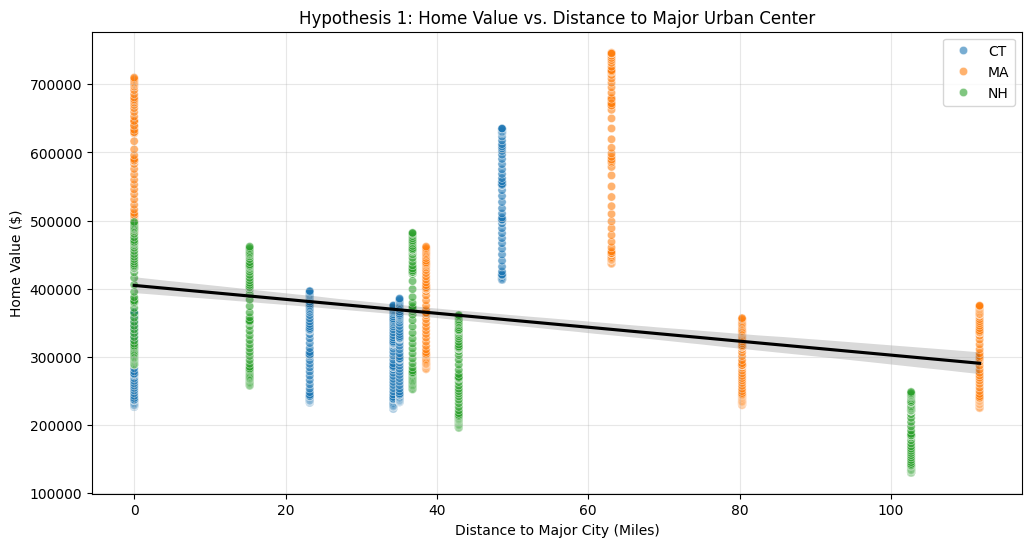

In [390]:
# Overall Correlation
overall_corr = final_df['DistanceToMajorCity_Miles'].corr(final_df['Zillow_Home_Value_Index'])
print(f"Overall Correlation (Distance vs Value): {overall_corr:.4f}")

# Correlation by State (Since each state has a different 'Hub')
state_corrs = final_df.groupby('StateName')[['DistanceToMajorCity_Miles', 'Zillow_Home_Value_Index']].corr().iloc[0::2, -1]
print("\nCorrelation by State:")
print(state_corrs)

# --- 2. Visualization (Scatter Plot with Regression Line) ---
plt.figure(figsize=(12, 6))

# Create a scatter plot with a regression line
# We color-code by State to see if the 'slope' differs by region
sns.scatterplot(data=final_df, x='DistanceToMajorCity_Miles', y='Zillow_Home_Value_Index', hue='StateName', alpha=0.6)

# Add a single trend line for the whole dataset to check the general hypothesis
sns.regplot(data=final_df, x='DistanceToMajorCity_Miles', y='Zillow_Home_Value_Index', scatter=False, color='black', line_kws={'label': 'Overall Trend'})

plt.title('Hypothesis 1: Home Value vs. Distance to Major Urban Center')
plt.xlabel('Distance to Major City (Miles)')
plt.ylabel('Home Value ($)')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

H₂: Demographic Increase and Price Increase

In [391]:
# Prepare the Population Data (from census files)
# Map the rates calculated to the State Name
pop_growth_data = {
    'CT': 2.66,
    'NH': 2.20,
    'MA': 2.02
}

In [392]:
# Sort to ensure we get the correct Start and End values
final_df = final_df.sort_values(by=['RegionName', 'Date'])

In [393]:
def calculate_appreciation(group):
    start_price = group['Zillow_Home_Value_Index'].iloc[0] # First available month (e.g. Jan 2019)
    end_price = group['Zillow_Home_Value_Index'].iloc[-1]  # Last available month (e.g. Dec 2024)
    
    # Calculate Percentage Growth
    price_growth_pct = ((end_price - start_price) / start_price) * 100
    
    return pd.Series({
        'PriceGrowthPct': price_growth_pct,
        'StateName': group['StateName'].iloc[0]
    })

In [394]:
# Group by Region and apply the calculation
metro_summary = final_df.groupby('RegionName').apply(calculate_appreciation).reset_index()

C:\Users\jacks\AppData\Local\Temp\ipykernel_12092\2423053018.py:2: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  metro_summary = final_df.groupby('RegionName').apply(calculate_appreciation).reset_index()


In [395]:
# --- 3. Merge Population Data ---
metro_summary['PopGrowthPct'] = metro_summary['StateName'].map(pop_growth_data)

In [407]:
# Check for missing data
print(metro_summary.head())

            RegionName  PriceGrowthPct StateName  PopGrowthPct
0  Barnstable Town, MA       70.610391        MA          2.02
1           Berlin, NH       91.087163        NH          2.20
2           Boston, MA       46.853409        MA          2.02
3       Bridgeport, CT       52.567004        CT          2.66
4          Concord, NH       79.192164        NH          2.20


In [408]:
print("\n[H2 Analysis] Regression: Price Appreciation ~ Population Growth")
h2_model = smf.ols("PriceGrowthPct ~ PopGrowthPct", data=metro_summary).fit()
print(h2_model.summary())


[H2 Analysis] Regression: Price Appreciation ~ Population Growth
                            OLS Regression Results                            
Dep. Variable:         PriceGrowthPct   R-squared:                       0.018
Model:                            OLS   Adj. R-squared:                 -0.052
Method:                 Least Squares   F-statistic:                    0.2519
Date:                Thu, 20 Nov 2025   Prob (F-statistic):              0.624
Time:                        20:32:29   Log-Likelihood:                -62.661
No. Observations:                  16   AIC:                             129.3
Df Residuals:                      14   BIC:                             130.9
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                   coef    std err          t      P>|t|      [0.025      0.975]
---------------------------------------------------------------

C:\Users\jacks\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\scipy\stats\_axis_nan_policy.py:418: UserWarning: `kurtosistest` p-value may be inaccurate with fewer than 20 observations; only n=16 observations were given.
  return hypotest_fun_in(*args, **kwds)


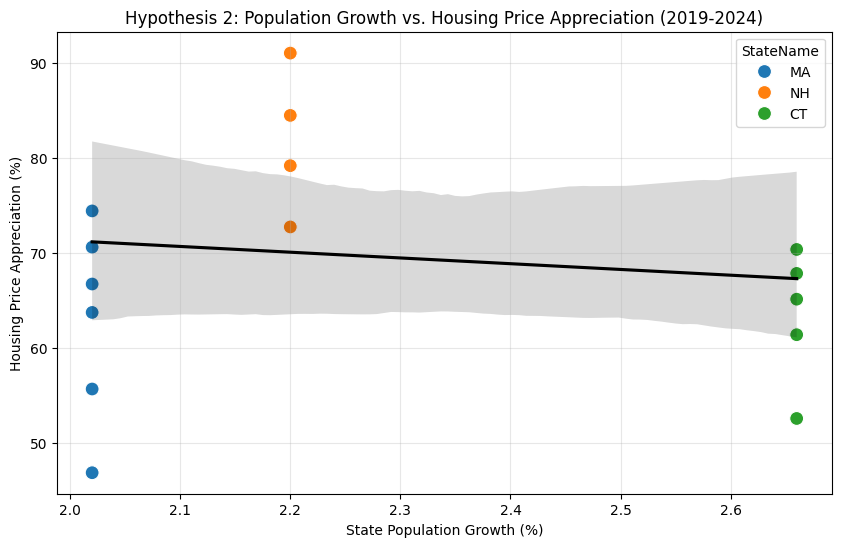

In [409]:
# Visualize
plt.figure(figsize=(10, 6))
sns.scatterplot(data=metro_summary, x='PopGrowthPct', y='PriceGrowthPct', hue='StateName', s=100)

# Add trendline
sns.regplot(data=metro_summary, x='PopGrowthPct', y='PriceGrowthPct', scatter=False, color='black')

plt.title('Hypothesis 2: Population Growth vs. Housing Price Appreciation (2019-2024)')
plt.xlabel('State Population Growth (%)')
plt.ylabel('Housing Price Appreciation (%)')
plt.grid(True, alpha=0.3)
plt.show()

H₃: The Effect of Mortgage Rates on Sales Volume

Overall Correlation (Mortage Rate vs Sales Volume): -0.1178

Correlation by State:
StateName                  
CT         MortgageRate30Yr   -0.333240
MA         MortgageRate30Yr   -0.102082
NH         MortgageRate30Yr   -0.246696
Name: Sales_Count, dtype: float64


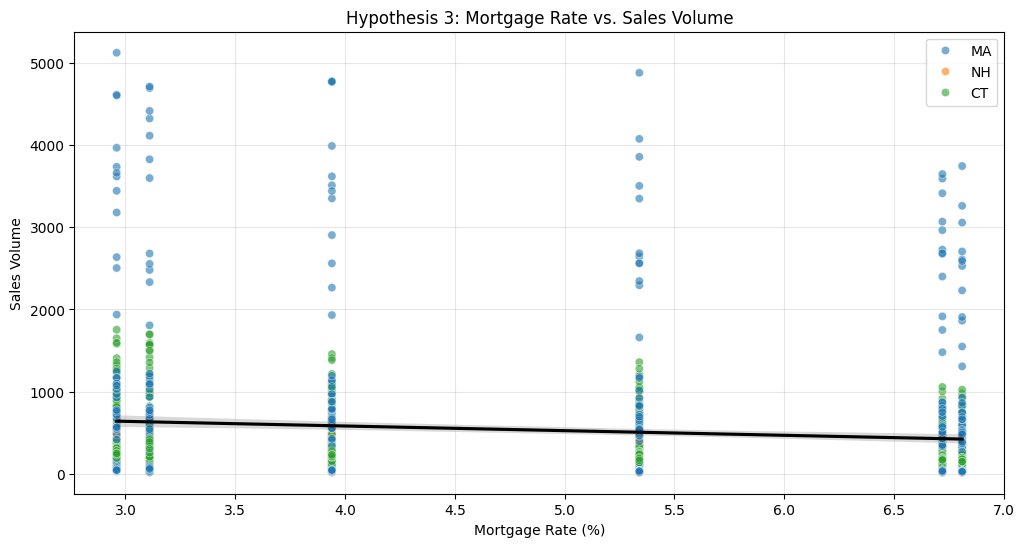

In [396]:
# Overall Correlation
overall_corr = final_df['MortgageRate30Yr'].corr(final_df['Sales_Count'])
print(f"Overall Correlation (Mortage Rate vs Sales Volume): {overall_corr:.4f}")

# Correlation by State (Since each state has a different 'Hub')
state_corrs = final_df.groupby('StateName')[['MortgageRate30Yr', 'Sales_Count']].corr().iloc[0::2, -1]
print("\nCorrelation by State:")
print(state_corrs)

# --- 2. Visualization (Scatter Plot with Regression Line) ---
plt.figure(figsize=(12, 6))

# Create a scatter plot with a regression line
# Color-code by State to see if the 'slope' differs by region
sns.scatterplot(data=final_df, x='MortgageRate30Yr', y='Sales_Count', hue='StateName', alpha=0.6)

# Add a single trend line for the whole dataset to check the general hypothesis
sns.regplot(data=final_df, x='MortgageRate30Yr', y='Sales_Count', scatter=False, color='black', line_kws={'label': 'Overall Trend'})

plt.title('Hypothesis 3: Mortgage Rate vs. Sales Volume')
plt.xlabel('Mortgage Rate (%)')
plt.ylabel('Sales Volume')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

H₄: Predictability of Affordability

In [397]:
# Create Affordable Target Variable
final_df['Affordable'] = (final_df['Zillow_Home_Value_Index'] <= 400000).astype(int)

In [398]:
# Feature Selection
feats = final_df[['DistanceToMajorCity_Miles',
                  'Sales_Count']].copy()

In [399]:
# ZIP frequency encoding
zip_freq = final_df['ZipCode'].value_counts(normalize=True)
feats['ZIP_freq'] = final_df['ZipCode'].map(zip_freq)

In [400]:
# Drop missing
model_df = pd.concat([feats, final_df['Affordable']], axis=1).dropna()


In [401]:
X = model_df.drop(columns=['Affordable'])
y = model_df['Affordable']

In [402]:
# Split Data
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, random_state=42, stratify=y
)

In [403]:
# Random Forest Classifier
rf = RandomForestClassifier(
    n_estimators=300,
    random_state=42,
    class_weight='balanced'
)

In [404]:
rf.fit(X_train, y_train)

RandomForestClassifier(class_weight='balanced', n_estimators=300,
                       random_state=42)

In [405]:
# Predictions
y_pred = rf.predict(X_test)
y_prob = rf.predict_proba(X_test)[:, 1]


In [406]:
print("=== H4 Classification Results ===")
print("Accuracy:", accuracy_score(y_test, y_pred))
print("Precision:", precision_score(y_test, y_pred))
print("Recall:", recall_score(y_test, y_pred))
print("ROC AUC:", roc_auc_score(y_test, y_prob))
print("\nConfusion Matrix:")
print(confusion_matrix(y_test, y_pred))

=== H4 Classification Results ===
Accuracy: 0.8888888888888888
Precision: 0.9078947368421053
Recall: 0.9324324324324325
ROC AUC: 0.9466414944356121

Confusion Matrix:
[[ 54  14]
 [ 10 138]]
